In [ ]:
# Cell1
# Mounts the Google Drive file system into the Colab environment to access dataset repositories and save model checkpoints.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell2
# Installs required geographic tracking packages and visualizes a random sample of images overlaid with their YOLO ground truth bounding box annotations.

# !pip install supervision matplotlib opencv-python

# import os
# import cv2
# import random
# import numpy as np
# import matplotlib.pyplot as plt
# import supervision as sv

# # 1. Paths and Configuration
# base_path = "/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/image_dataset/"
# classes = ['weed', 'cotton'] # Order matters here!

# # 2. Select Random Sample
# all_images = [f for f in os.listdir(base_path) if f.endswith('.jpg')]
# sample_images = random.sample(all_images, min(4, len(all_images)))

# # 3. Setup Supervision Annotators
# box_annotator = sv.BoxAnnotator(thickness=2)
# label_annotator = sv.LabelAnnotator(text_thickness=2, text_scale=1)

# images_to_plot = []
# titles = []

# # 4. Process and Annotate
# for img_name in sample_images:
#     img_path = os.path.join(base_path, img_name)
#     image = cv2.imread(img_path)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     h, w, _ = image.shape

#     txt_name = img_name.replace('.jpg', '.txt')
#     txt_path = os.path.join(base_path, txt_name)

#     boxes = []
#     class_ids = []

#     if os.path.exists(txt_path):
#         with open(txt_path, 'r') as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) >= 5:
#                     class_id = int(parts[0])
#                     cx, cy, bw, bh = map(float, parts[1:5])

#                     x1 = (cx - bw / 2) * w
#                     y1 = (cy - bh / 2) * h
#                     x2 = (cx + bw / 2) * w
#                     y2 = (cy + bh / 2) * h

#                     boxes.append([x1, y1, x2, y2])
#                     class_ids.append(class_id)

#     if boxes:
#         detections = sv.Detections(
#             xyxy=np.array(boxes, dtype=np.float32),
#             class_id=np.array(class_ids, dtype=int)
#         )

#         # # FIX 1: Safely map class IDs. If a number doesn't exist in your list, it prints the raw number instead of crashing.
#         labels = [
#             classes[cls_id] if cls_id < len(classes) else f"Unknown ID: {cls_id}"
#             for cls_id in detections.class_id
#         ]

#         annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)
#         annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)
#     else:
#         annotated_image = image.copy()

#     images_to_plot.append(annotated_image)

#     titles.append(f"{img_name} ({len(boxes)} detections)")

# # 5. Plot Output
# print("Visualizing ground truth annotations...")
# sv.plot_images_grid(
#     images=images_to_plot,
#     titles=titles,
#     grid_size=(2, 2),
#     size=(16, 16)
# )

In [ ]:
# Cell 3
# Verifies annotation data integrity by reading and displaying the textual contents of selected YOLO annotation files.

# import os

# print("Content of annotation files:")
# for img_name in sample_images:
#     txt_name = img_name.replace('.jpg', '.txt')
#     txt_path = os.path.join(base_path, txt_name)

#     print(f"\n--- {txt_name} ---")
#     if os.path.exists(txt_path):
#         with open(txt_path, 'r') as f:
#             content = f.read()
#             print(content)
#     else:
#         print(f"Annotation file not found for {img_name}")

In [ ]:
# Cell 4
# Identifies valid image-annotation pairs and performs a comprehensive 80/20 train-test split for unbiased model evaluation.

# from sklearn.model_selection import train_test_split

# # 1. Define source directory
# source_dir = base_path

# # 2. & 3. Identify valid image-annotation pairs
# valid_base_names = []
# all_files = os.listdir(source_dir)
# image_files = [f for f in all_files if f.endswith('.jpg')]

# for img_file in image_files:
#     base_name = os.path.splitext(img_file)[0]
#     txt_file = base_name + '.txt'
#     if txt_file in all_files:
#         valid_base_names.append(base_name)

# # 4. & 5. Split the data (80% train, 20% test)
# train_names, test_names = train_test_split(
#     valid_base_names,
#     test_size=0.20,
#     random_state=42
# )

# # 6. Print results
# print(f"Total valid pairs found: {len(valid_base_names)}")
# print(f"Training set size: {len(train_names)} ({len(train_names)/len(valid_base_names)*100:.1f}%)")
# print(f"Testing set size: {len(test_names)} ({len(test_names)/len(valid_base_names)*100:.1f}%)")

In [ ]:
# Cell 5
# Initializes the structured directory hierarchy required by the YOLO framework, separating data into targeted train and test structures.

# import os

# # 1. Define root destination path
# dest_root = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/dataset_split/'

# # 2. Define subdirectories
# subdirs = [
#     'train/images',
#     'train/labels',
#     'test/images',
#     'test/labels'
# ]

# # 3. Create directory structure
# print("Creating directory structure...")
# for subdir in subdirs:
#     path = os.path.join(dest_root, subdir)
#     os.makedirs(path, exist_ok=True)
#     print(f"Created or verified: {path}")

# print("\nDirectory setup complete.")

In [ ]:
# Cell 6
# Methodically copies the correctly identified training and testing source images alongside their corresponding label files into the appropriate split directories.

# ## CAUTION: DON'T EXECUTE UNTIL YOU ARE FREE TO USE THE RUN TIME OF THE GPU ****

# ## THIS CMD WILL TAKE AROUND 1 HOUR (IF YOU HAVE A CONNECTED GOOGLE DRIVE)

# ## PLEASE RUN THIS CMD OFFLINE FOR BETTER I/O SPEEDS

# import shutil

# def copy_split_files(file_names, set_type):
#     """Helper function to copy images and labels for a specific split."""
#     for name in file_names:
#         # Copy image
#         img_src = os.path.join(source_dir, name + '.jpg')
#         img_dst = os.path.join(dest_root, f'{set_type}/images', name + '.jpg')
#         shutil.copy(img_src, img_dst)

#         # Copy label
#         lbl_src = os.path.join(source_dir, name + '.txt')
#         lbl_dst = os.path.join(dest_root, f'{set_type}/labels', name + '.txt')
#         shutil.copy(lbl_src, lbl_dst)

# # Execute copying for training set
# print("Copying training files...")
# copy_split_files(train_names, 'train')

# # Execute copying for testing set
# print("Copying testing files...")
# copy_split_files(test_names, 'test')

# print(f"\nSuccessfully copied {len(train_names)} training pairs and {len(test_names)} testing pairs to {dest_root}.")

In [ ]:
# Cell 7
# Installs the core `ultralytics` package and rigorously verifies YOLOv8 dependency structures and environment readiness.

!pip install ultralytics

import ultralytics
from ultralytics import YOLO



Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [ ]:
# cell 8

# Verify installation and environment readiness
ultralytics.checks()

In [ ]:
#cell9
# Generates and persists the YAML configuration file extensively detailing dataset locations and the corresponding class label schema.

# import yaml

# # 1. Define dataset configuration
# data_config = {
#     'train': '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/dataset_split/train/images',
#     'val': '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/dataset_split/test/images',
#     'nc': 2,
#     'names': ['weed', 'cotton']
# }

# # 2. Define path and save YAML
# yaml_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/data.yaml'

# with open(yaml_path, 'w') as f:
#     yaml.dump(data_config, f, default_flow_style=False)

# # 3. Print the final YAML string to verify structure
# print(f"YAML file saved to: {yaml_path}\n")
# print("--- YAML Content ---")
# print(yaml.dump(data_config, default_flow_style=False))

In [ ]:
#cell10
# Loads the pre-trained standard YOLOv8n object detection model weights into memory acting as an optimization foundation for transfer learning.

# from ultralytics import YOLO

# # 1. Load the pre-trained YOLOv8n model
# model = YOLO('yolov8n.pt')

# # 2. Print the model object to confirm initialization
# print(model)

In [ ]:
#cell11
# Initiates the model fine-tuning process by executing the comprehensive training subroutine on the custom dataset for 50 specified epochs.

# # Execute the training process
# results = model.train(
#     data='/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/data.yaml',
#     epochs=50,
#     imgsz=640
# )

# print("Training complete.")
# print(f"Results saved to: {results.save_dir}")

In [ ]:
#cell12
# Loads the finalized custom trained weights and executes batch predictions on test split images, generating verified visual predictive annotations.

from ultralytics import YOLO
import os

# 1. Load the trained model weights
# Note: Ensure the path to best_weed_detector.pt is correct on your Drive
model_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/best_weed_detector.pt'
model = YOLO(model_path)

# 2. Define the source path for test images
test_images_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/dataset_split/test/images'

# 3. Run detection
# results will be saved to runs/detect/predict by default
results = model.predict(
    source=test_images_path,
    conf=0.25,
    save=True
)

print(f"Inference complete. Results saved to the 'runs/detect/predict' folder.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1850 /content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/dataset_split/test/images/MAX_0005_28.jpg: 480x640 2 weeds, 107.5ms
image 2/1850 /content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/dataset_split/test/images/MAX_0005_35.jpg: 480x640 1 weed, 8.3ms
image 3/1850 /content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Datas

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 41.4±17.6 MB/s, size: 122.9 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/dataset_split/test/labels.cache... 1850 images, 30 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1850/1850 258.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 116/116 3.1it/s 36.9s
                   all       1850      11056      0.798       0.78      0.849        0.5
                  weed        264       1164      0.749      0.666       0.76      0.391
                cotton       1605       9892      0.847      0.894      0.938      0.609
Speed: 1.3ms preprocess, 3.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Saving /content/runs/detect/val/predict

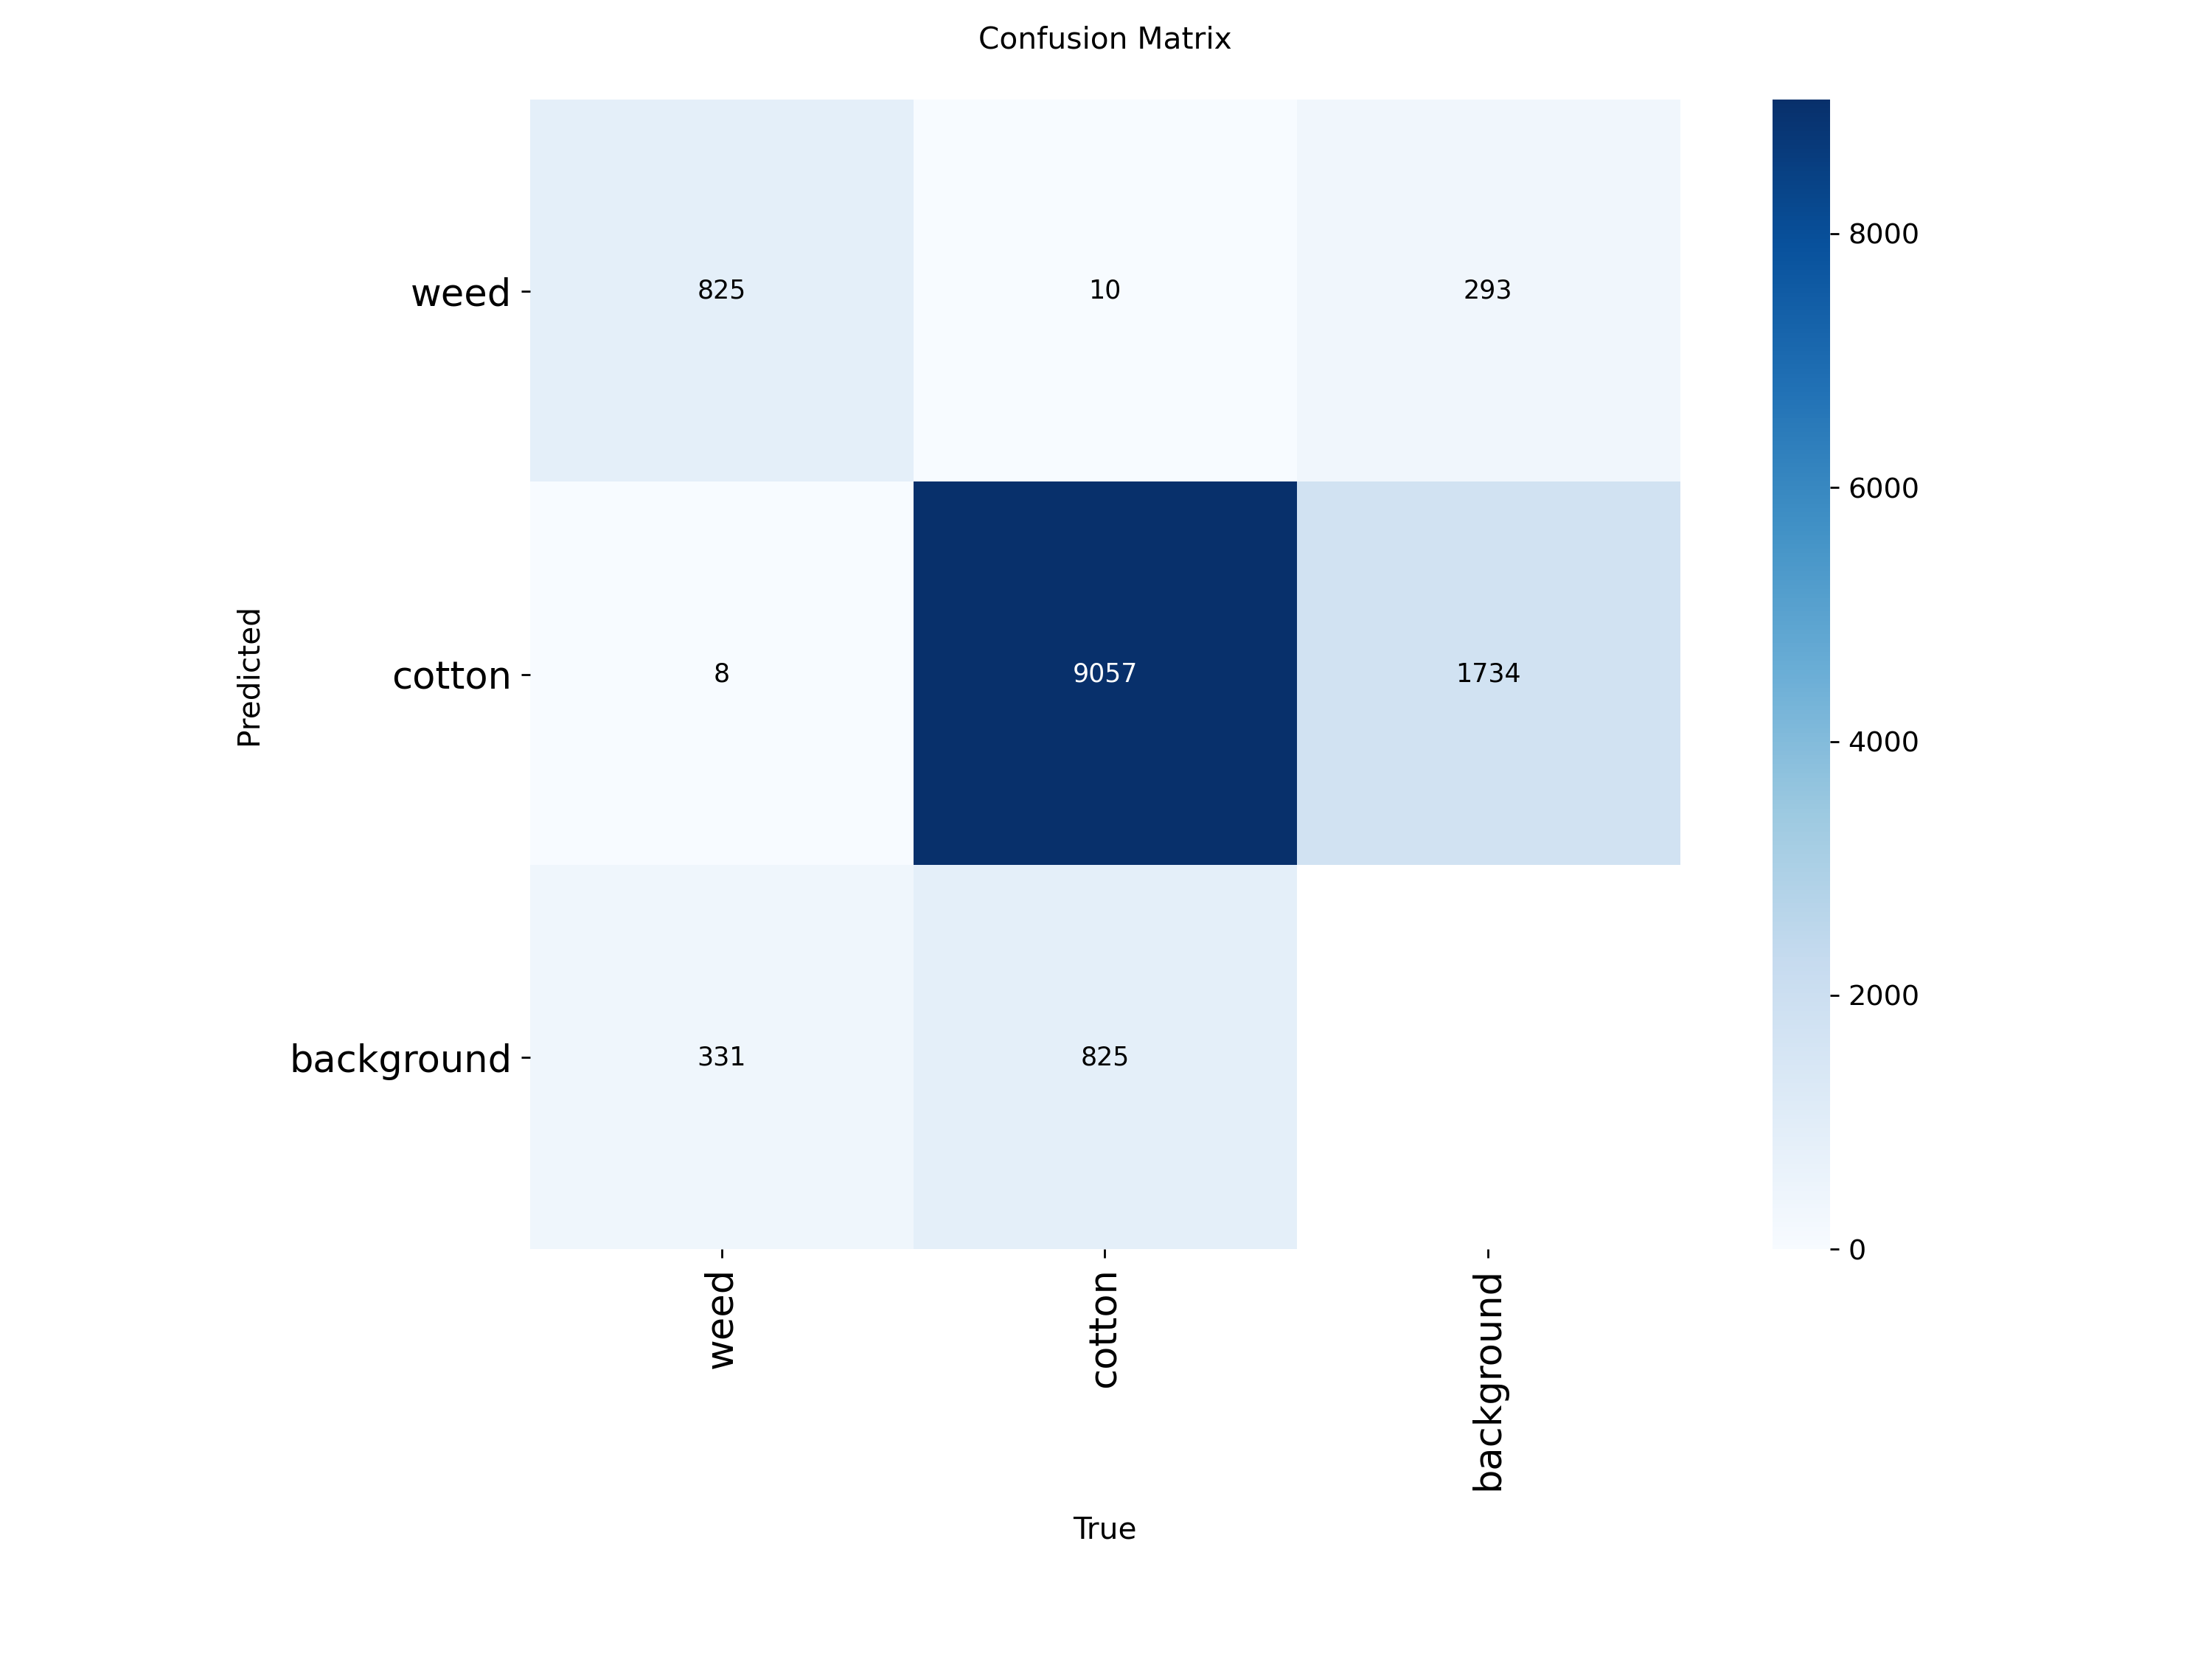

In [ ]:
#cell13
# Executes formal validation evaluations to compute advanced performance metrics including mAP, Precision, Recall, alongside visual artifact aggregation.

from ultralytics import YOLO
import os
from IPython.display import Image, display

# 1. Load the trained model
model_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/best_weed_detector.pt'
model = YOLO(model_path)

# 2. Run validation on the test set
# We point to the data.yaml which defines our validation (test) paths
metrics = model.val(
    data='/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/data.yaml',
    split='val', # This uses the 'val' path defined in your yaml (which is our test split)
    imgsz=640,
    save_json=True
)

print("\n--- Evaluation Summary ---")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# 3. Display the Confusion Matrix
confusion_matrix_path = os.path.join(metrics.save_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print("\nConfusion Matrix:")
    display(Image(filename=confusion_matrix_path))

# 4. Display Precision-Recall Curve
pr_curve_path = os.path.join(metrics.save_dir, 'PR_curve.png')
if os.path.exists(pr_curve_path):
    print("\nPrecision-Recall Curve:")
    display(Image(filename=pr_curve_path))

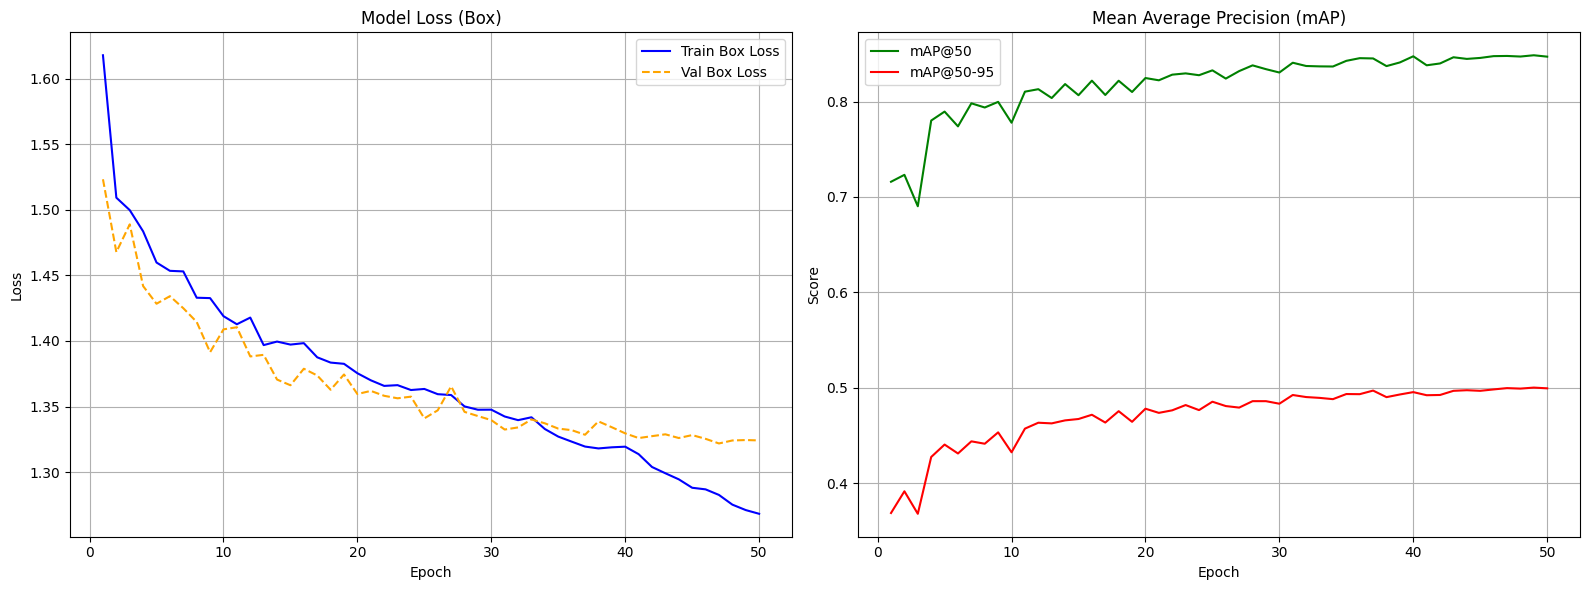

In [ ]:
#cell14
# Parses the generated execution metrics to graph overarching model tracking metrics, focusing specifically on train versus validation Box Loss convergence.

import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Path to the training results
results_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/Results_from_Training/results.csv'

if os.path.exists(results_path):
    # 2. Load the results CSV
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip() # Clean column names

    # 3. Create the plot
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Training and Validation Losses
    axs[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
    axs[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange', linestyle='--')
    axs[0].set_title('Model Loss (Box)')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # Plot mAP Metrics
    axs[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
    axs[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='red')
    axs[1].set_title('Mean Average Precision (mAP)')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Score')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print(f"Results file not found at {results_path}. If you loaded a pre-trained model, please ensure the results.csv is available in the training folder.")

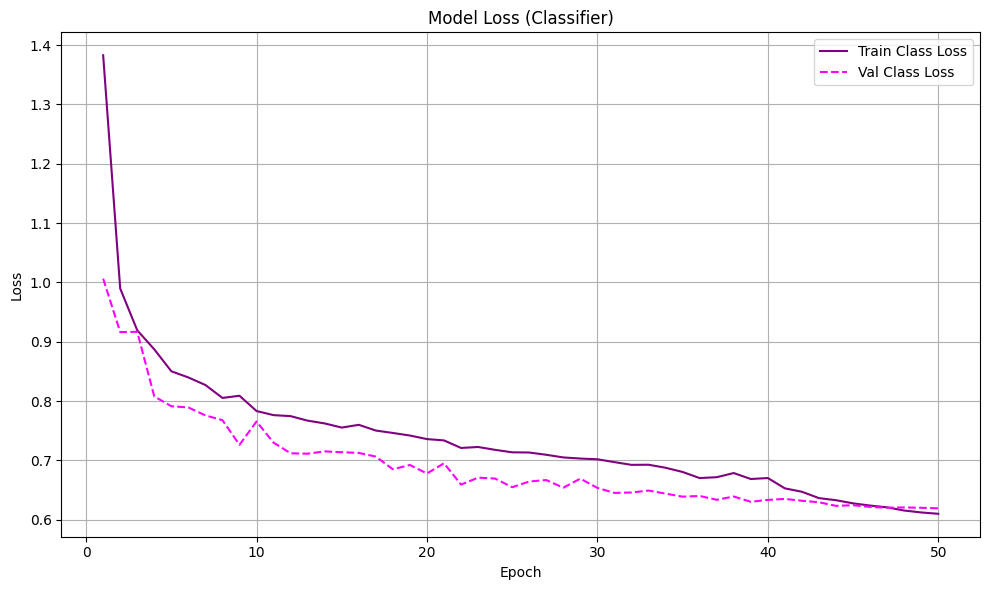

In [ ]:
#cell15
# Illustrates progression over epoch sequences detailing Classifier Loss metrics to evaluate separation accuracy between specific cotton and weed entities.

import matplotlib.pyplot as plt
import os
import pandas as pd

results_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/Results_from_Training/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip() # Clean column names

    # Plot Training and Validation Classifier Losses
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', color='purple')
    plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', color='magenta', linestyle='--')
    plt.title('Model Loss (Classifier)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Results file not found at {results_path}. Please ensure the results.csv is available in the training folder.")

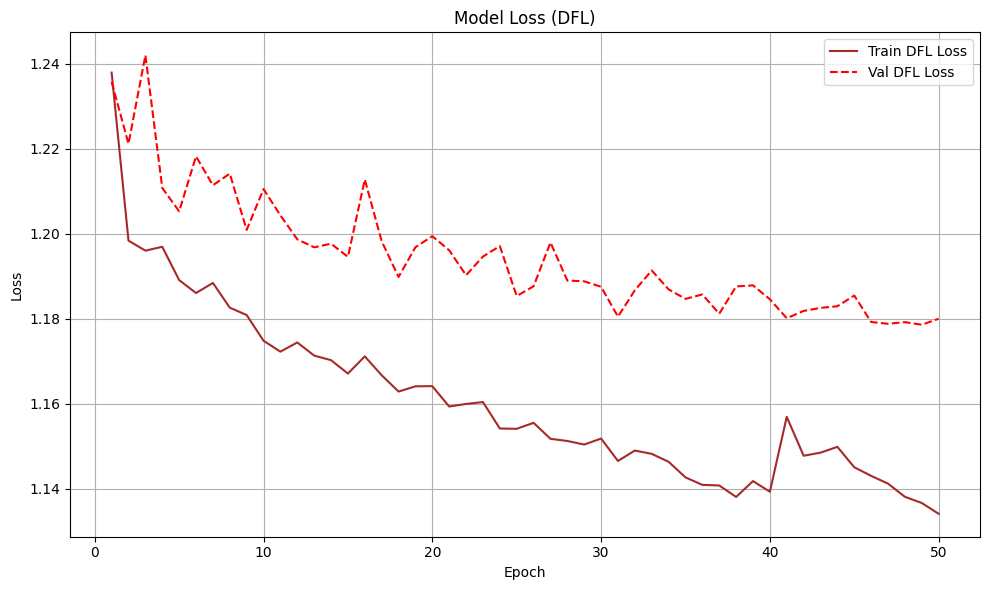

In [ ]:
#cell16
# Visualizes the Distribution Focal Loss (DFL) tracking model boundary convergence predicting accurate bounding box localizations longitudinally.

import matplotlib.pyplot as plt
import os
import pandas as pd

results_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/Results_from_Training/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip() # Clean column names

    # Plot Training and Validation Distribution Focal Losses
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss', color='brown')
    plt.plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss', color='red', linestyle='--')
    plt.title('Model Loss (DFL)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Results file not found at {results_path}. Please ensure the results.csv is available in the training folder.")

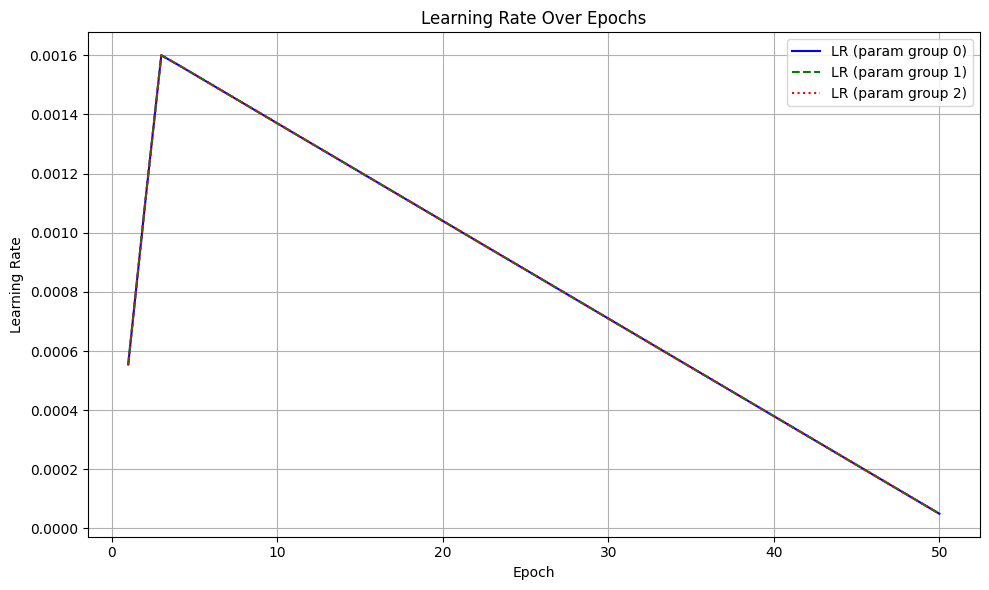

In [ ]:
#cell17
# Plots an overarching view of systemic parameter group varying learning rates, observing how dynamic step sizing influences gradient convergence.

import matplotlib.pyplot as plt
import os
import pandas as pd

results_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/Results_from_Training/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip() # Clean column names

    # Plot Learning Rates
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['lr/pg0'], label='LR (param group 0)', color='blue')
    plt.plot(df['epoch'], df['lr/pg1'], label='LR (param group 1)', color='green', linestyle='--')
    plt.plot(df['epoch'], df['lr/pg2'], label='LR (param group 2)', color='red', linestyle=':')
    plt.title('Learning Rate Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Results file not found at {results_path}. Please ensure the results.csv is available in the training folder.")

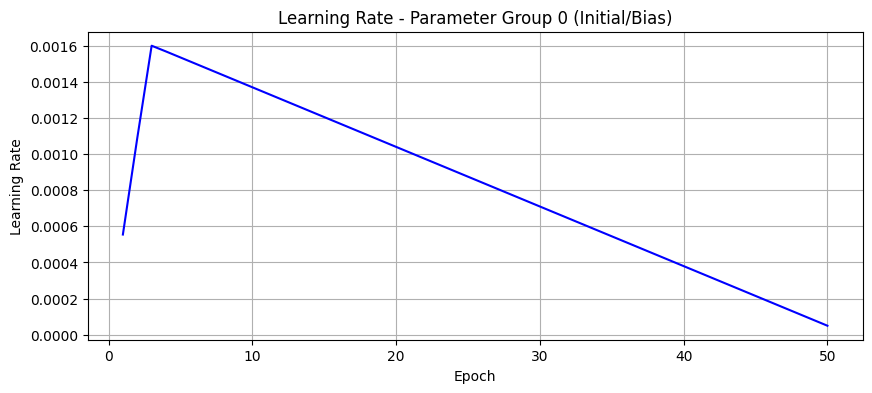

In [ ]:
#cell18
# Details learning rate adjustment dynamics specifically isolated to optimization strategies evaluating the Initial/Bias parameter network group.

import matplotlib.pyplot as plt
import os
import pandas as pd

results_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/Results_from_Training/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()

    plt.figure(figsize=(10, 4))
    plt.plot(df['epoch'], df['lr/pg0'], label='LR (pg0)', color='blue')
    plt.title('Learning Rate - Parameter Group 0 (Initial/Bias)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.show()
else:
    print('Results file not found.')

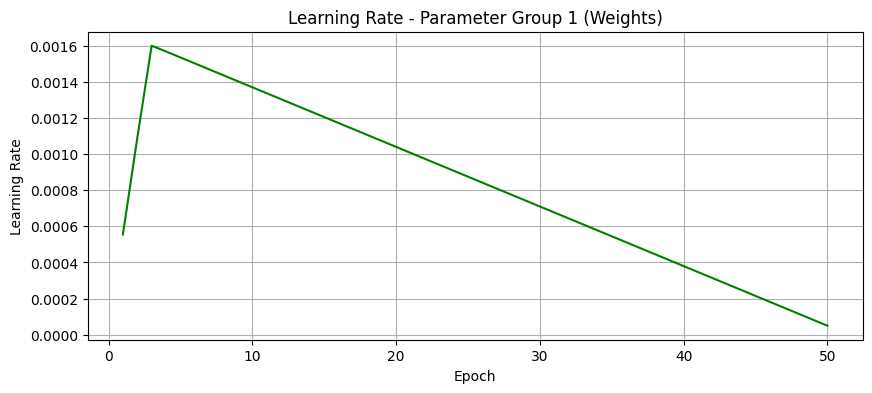

In [ ]:
#cell19
# Monitors specific decay mechanics intrinsically isolating optimization manipulations applied strictly alongside specific predictive Network Weights.

import matplotlib.pyplot as plt
import os
import pandas as pd

if os.path.exists(results_path):
    plt.figure(figsize=(10, 4))
    plt.plot(df['epoch'], df['lr/pg1'], label='LR (pg1)', color='green')
    plt.title('Learning Rate - Parameter Group 1 (Weights)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.show()

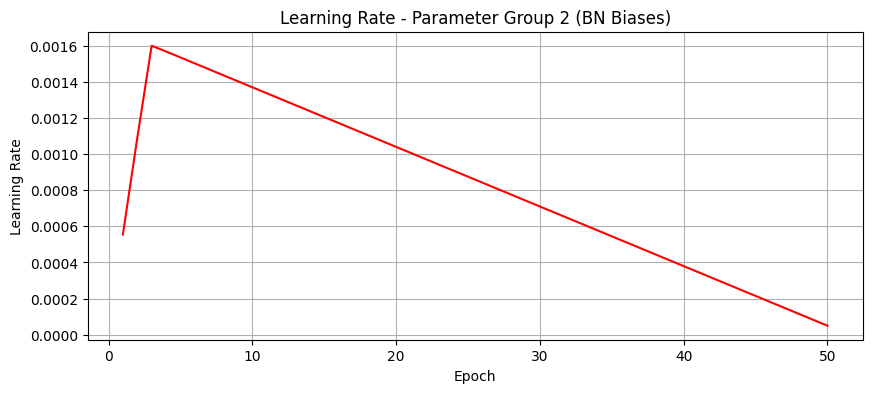

In [ ]:
#cell20
# Observes progressive optimization tuning evaluating batch normalization parameters via targeted analysis over tracked parameter learning rate mapping.

import matplotlib.pyplot as plt
import os
import pandas as pd

if os.path.exists(results_path):
    plt.figure(figsize=(10, 4))
    plt.plot(df['epoch'], df['lr/pg2'], label='LR (pg2)', color='red')
    plt.title('Learning Rate - Parameter Group 2 (BN Biases)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.show()

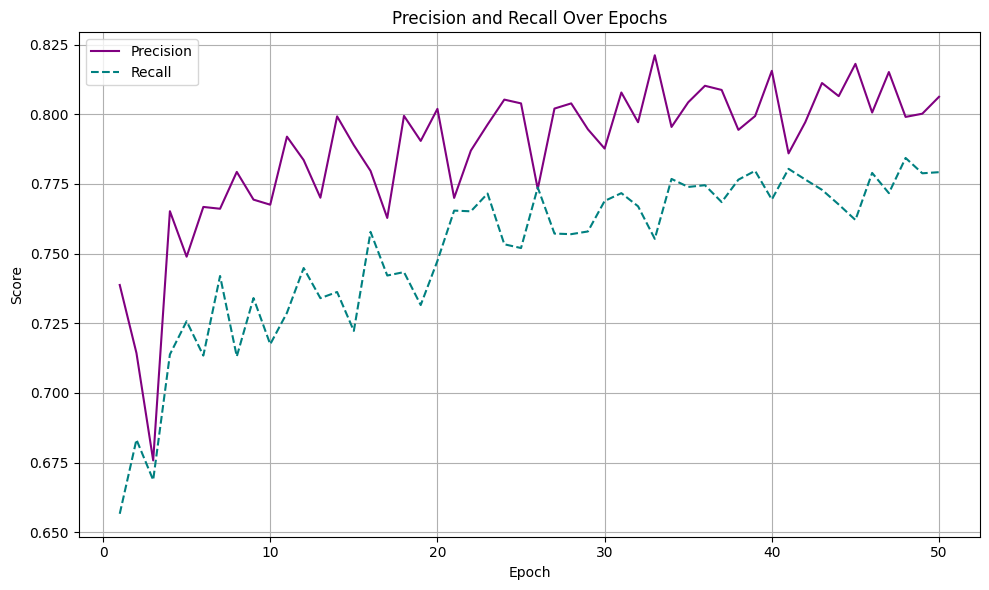

In [ ]:
#cell21
# Evaluates overall predictive model balancing tracking Precision functionality against generalized Recall metric mappings distributed across training iterations.

import matplotlib.pyplot as plt
import os
import pandas as pd

results_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/Results_from_Training/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip() # Clean column names

    # Plot Precision and Recall Metrics
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='purple')
    plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='teal', linestyle='--')
    plt.title('Precision and Recall Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Results file not found at {results_path}. Please ensure the results.csv is available in the training folder.")

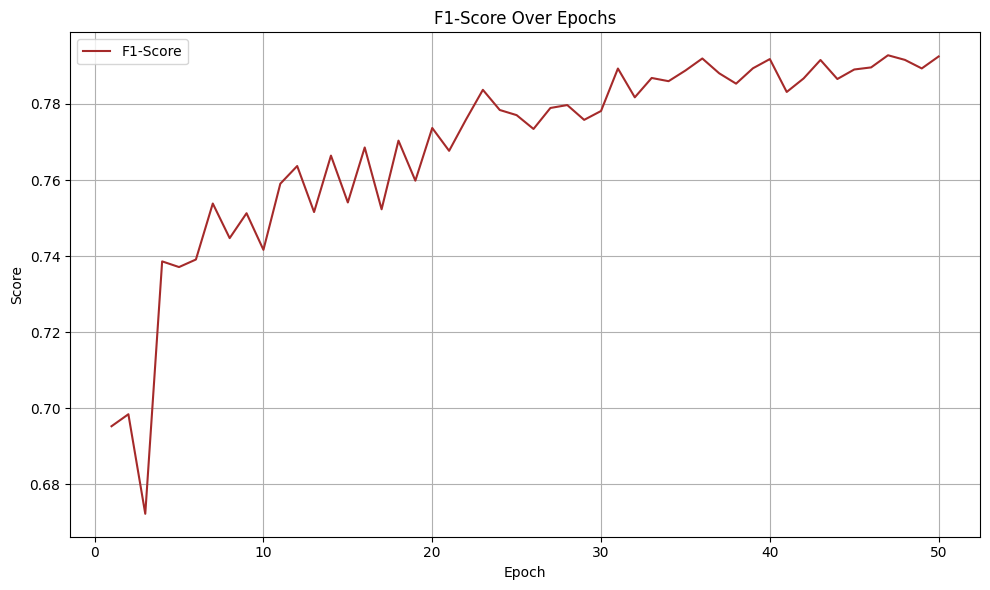

In [ ]:
#cell22
# Computes and displays the harmonic alignment metric over progressive epochs, specifically mapping performance balance across differing recall constraints.

import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

results_path = '/content/drive/MyDrive/Colab Notebooks/Data_New_Weed/Annotated UAV Image Dataset for Object Detection U/Results_from_Training/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip() # Clean column names

    # Calculate F1-Score from Precision and Recall
    # F1 = 2 * (Precision * Recall) / (Precision + Recall)
    # Avoid division by zero if Precision + Recall is 0
    df['metrics/f1'] = np.where(
        (df['metrics/precision(B)'] + df['metrics/recall(B)']) == 0,
        0,
        2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) /
        (df['metrics/precision(B)'] + df['metrics/recall(B)'])
    )

    # Plot F1-Score Metric
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['metrics/f1'], label='F1-Score', color='brown')
    plt.title('F1-Score Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Results file not found at {results_path}. Please ensure the results.csv is available in the training folder.")

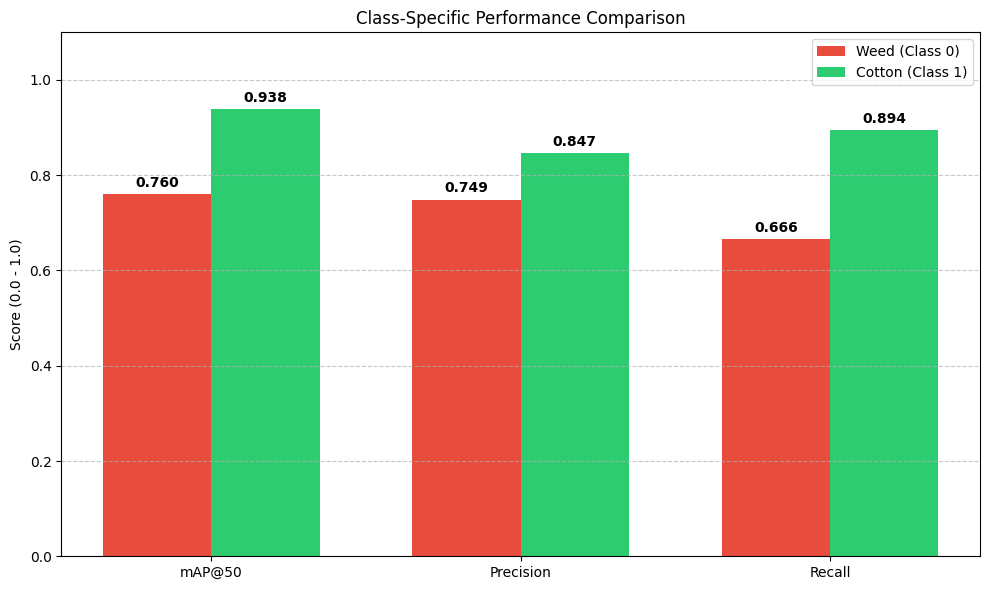

In [ ]:
#cell23
# Generates cross comparative visualizations distributing performance measures directly mapping identification strengths segmented per independent target class.

import matplotlib.pyplot as plt
import numpy as np

# Data from the validation summary
classes = ['weed', 'cotton']
metrics_names = ['mAP@50', 'Precision', 'Recall']

# Scores mapped from the provided results
# Weed: mAP50=0.760, P=0.749, R=0.666
# Cotton: mAP50=0.938, P=0.847, R=0.894
weed_scores = [0.760, 0.749, 0.666]
cotton_scores = [0.938, 0.847, 0.894]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, weed_scores, width, label='Weed (Class 0)', color='#e74c3c')
rects2 = ax.bar(x + width/2, cotton_scores, width, label='Cotton (Class 1)', color='#2ecc71')

ax.set_ylabel('Score (0.0 - 1.0)')
ax.set_title('Class-Specific Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', weight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Confusion Matrix (Test Set) ###


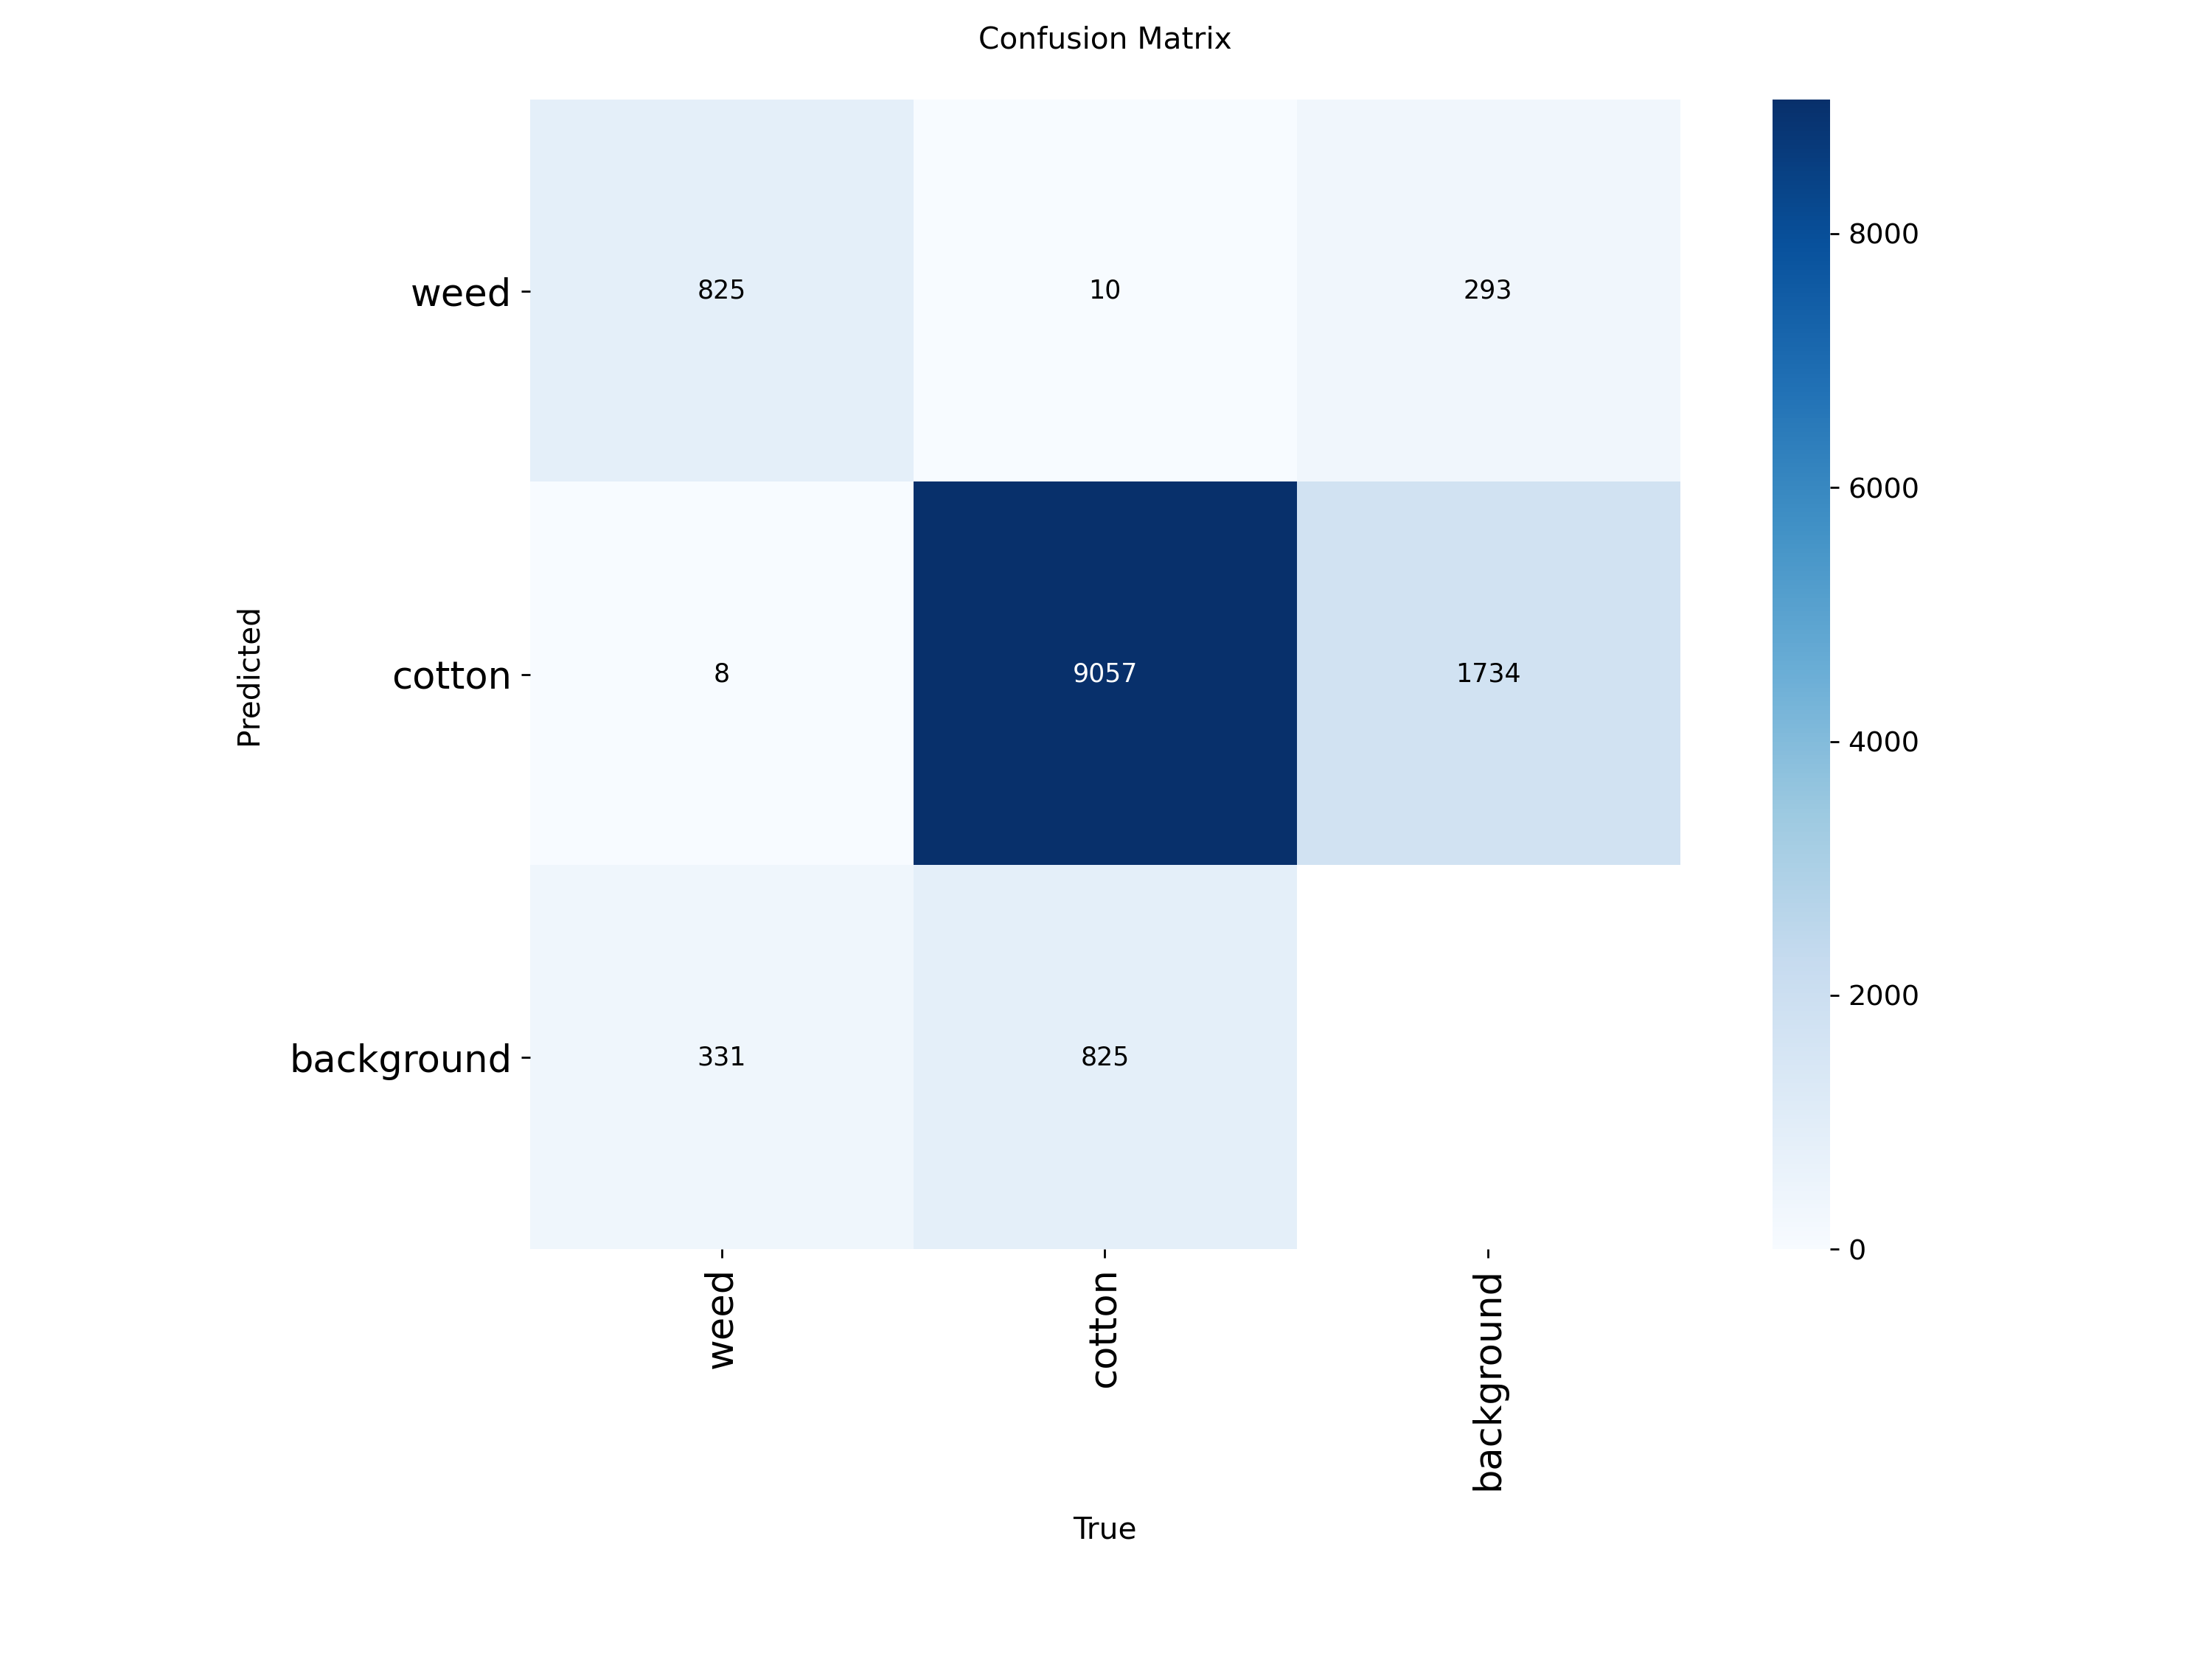


### Normalized Confusion Matrix (Test Set) ###


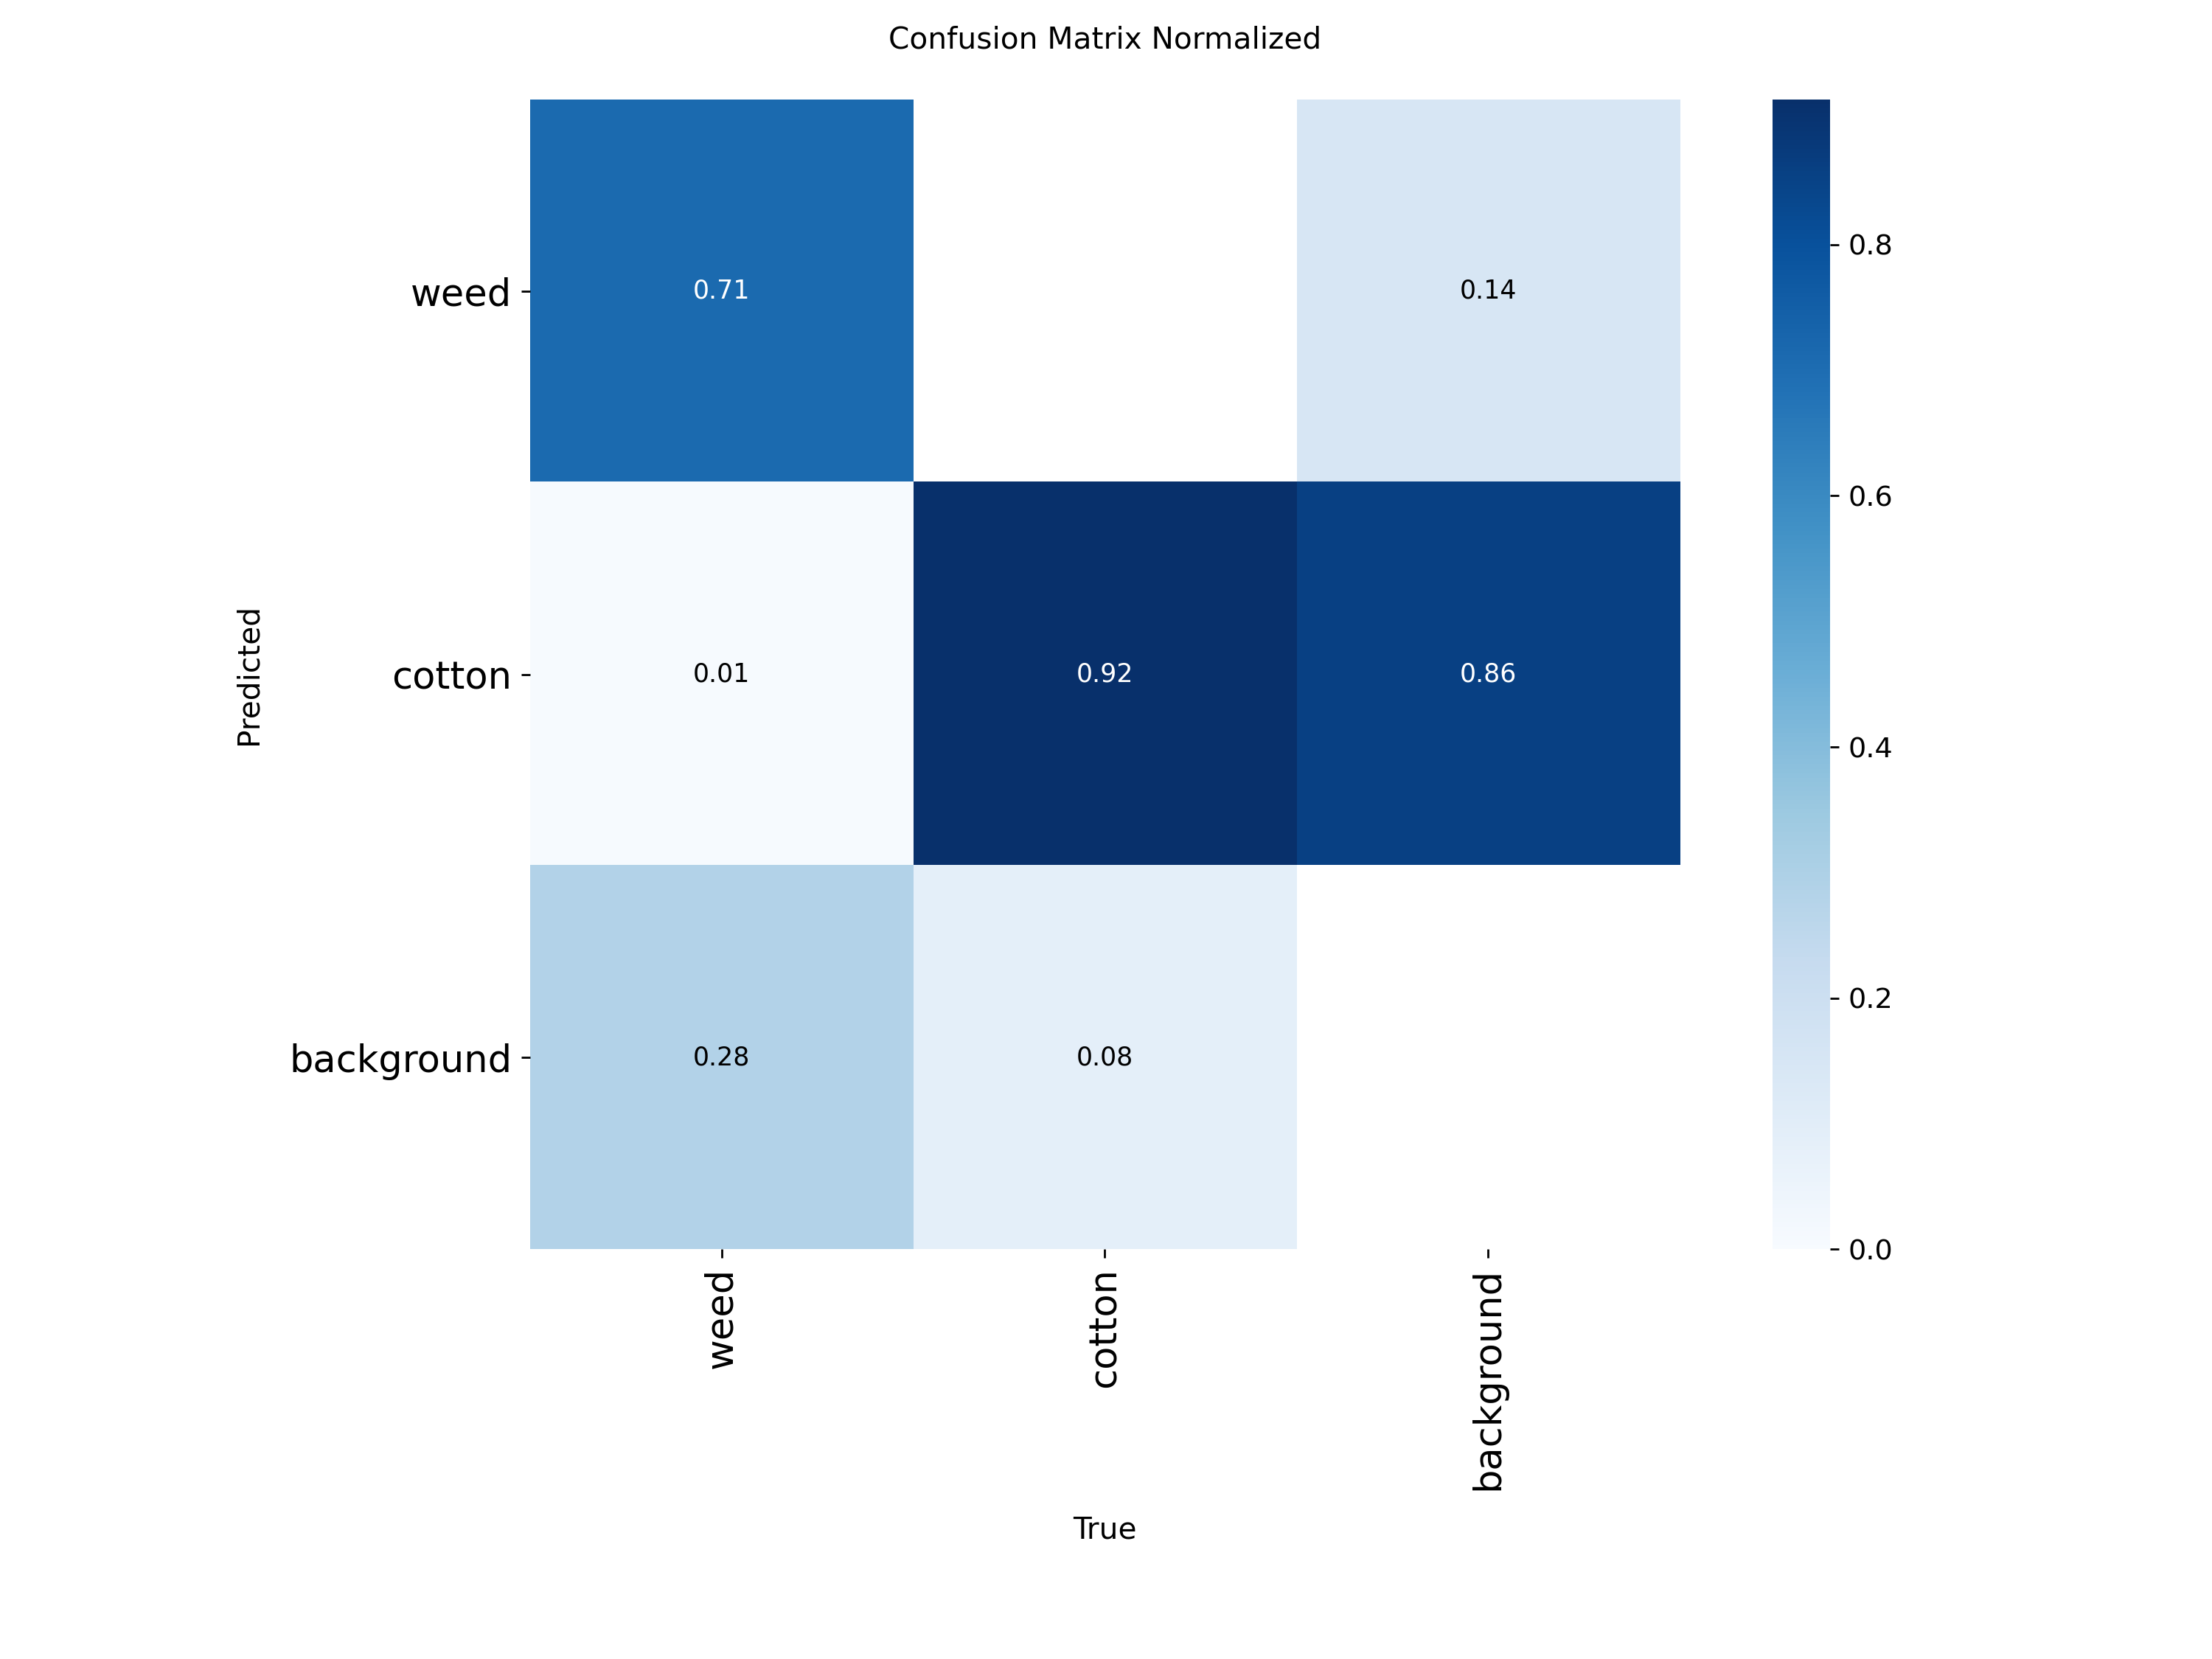

In [ ]:
#cell24
# Renders structurally formatted normalized and standard Confusion Matrices verifying systematic true-positive hit identifications across testing cohorts.

from IPython.display import Image, display
import os

# Path where validation results were saved during model.val()
val_results_path = '/content/runs/detect/val/'

# 1. Display Standard Confusion Matrix
cm_path = os.path.join(val_results_path, 'confusion_matrix.png')
if os.path.exists(cm_path):
    print("### Confusion Matrix (Test Set) ###")
    display(Image(filename=cm_path))
else:
    print(f"Confusion matrix not found at {cm_path}. Please ensure model.val() has been run.")

# 2. Display Normalized Confusion Matrix
cm_norm_path = os.path.join(val_results_path, 'confusion_matrix_normalized.png')
if os.path.exists(cm_norm_path):
    print("\n### Normalized Confusion Matrix (Test Set) ###")
    display(Image(filename=cm_norm_path))


In [ ]:
#cell25
# Presents probability artifacts utilizing calculated F1 Confidence parameters natively bounding structural confidence across inference confidence threshold mappings.

import os
from IPython.display import Image, display

# Path to PR Curve generated during testing
pr_curve_path = '/content/runs/detect/val/PR_curve.png'
f1_curve_path = '/content/runs/detect/val/F1_curve.png'

if os.path.exists(pr_curve_path):
    print("### Precision-Recall Curve (Test Set) ###")
    display(Image(filename=pr_curve_path))

if os.path.exists(f1_curve_path):
    print("\n### F1-Confidence Curve (Test Set) ###")
    display(Image(filename=f1_curve_path))


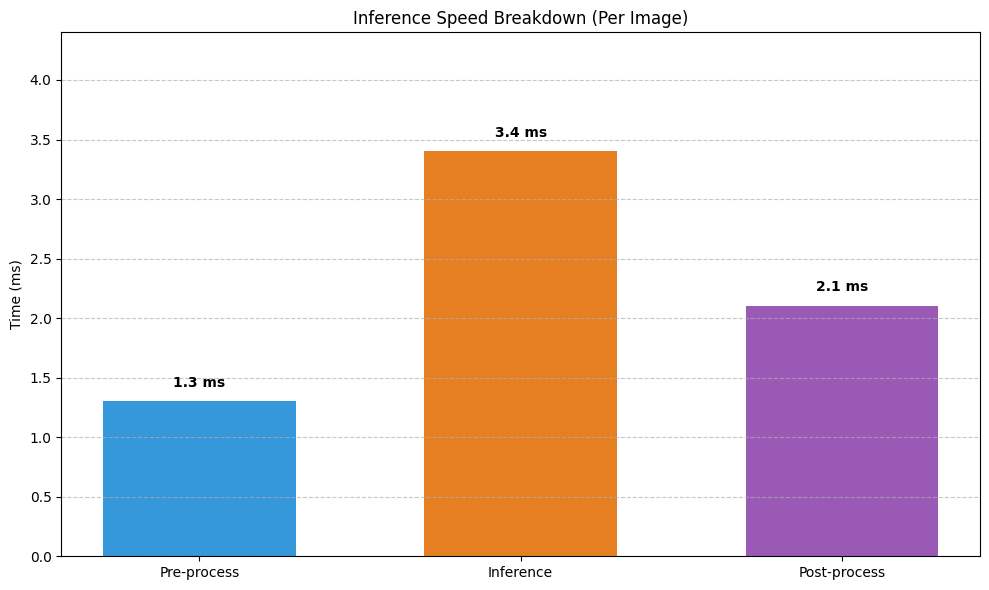

Total latency per image: 6.80 ms
Estimated Throughput: 147.06 FPS


In [ ]:
#cell26
# Quantifies and graphs inference variables indicating pipeline application latencies, calculating breakdown speeds characterizing independent module processes natively.

import matplotlib.pyplot as plt
import numpy as np

# Speed metrics from the validation output (in milliseconds per image)
# Values from your previous model.val() output:
# Speed: 1.3ms preprocess, 3.4ms inference, 0.0ms loss, 2.1ms postprocess per image

stages = ['Pre-process', 'Inference', 'Post-process']
speeds = [1.3, 3.4, 2.1]

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e67e22', '#9b59b6']

bars = plt.bar(stages, speeds, color=colors, width=0.6)

plt.ylabel('Time (ms)')
plt.title('Inference Speed Breakdown (Per Image)')
plt.ylim(0, max(speeds) + 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height} ms', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

total_speed = sum(speeds)
print(f"Total latency per image: {total_speed:.2f} ms")
print(f"Estimated Throughput: {1000/total_speed:.2f} FPS")

<!-- #cell27: Outlines formal arithmetic structures defining logical progression mappings for calculating algorithmic Frames Per Second limits and potential efficiency indicators. -->

### FPS Calculation Breakdown

To calculate the Frames Per Second (FPS), we use the following steps:

1. **Total Latency ($T_{total}$)**: Sum of Pre-processing, Inference, and Post-processing times.
   $$T_{total} = T_{preprocess} + T_{inference} + T_{postprocess}$$
   $$T_{total} = 1.3ms + 3.4ms + 2.1ms = 6.8ms$$

2. **Convert to Seconds**: Since the metrics are in milliseconds, we divide by 1000.
   $$T_{seconds} = \frac{6.8}{1000} = 0.0068 \text{ seconds}$$

3. **Calculate FPS**: FPS is the reciprocal of the time per frame.
   $$\text{FPS} = \frac{1}{T_{seconds}} = \frac{1}{0.0068} \approx 147.06$$

This means the model can process approximately **147 frames every second**.

In [ ]:
#cell28
# Executes pythonic mathematical verification sequences structurally affirming total performance boundary expectations establishing production functional speed viability.

# Python verification of the logic
preprocess = 1.3
inference = 3.4
postprocess = 2.1

total_latency_ms = preprocess + inference + postprocess
fps = 1000 / total_latency_ms

print(f"Total Latency: {total_latency_ms} ms")
print(f"Calculation: 1000 / {total_latency_ms} = {fps:.2f} FPS")

Total Latency: 6.800000000000001 ms
Calculation: 1000 / 6.800000000000001 = 147.06 FPS
